## Product Clustering

**Goal**
- Group reviews into 4–6 meta categories using embeddings.

In [2]:
!pip install sentence-transformers
import pandas as pd
from pathlib import Path

df = pd.read_csv(
    "/content/clean_reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,name,reviews.rating,reviews.text,sentiment,clean_review
0,AmazonBasics AAA Performance Alkaline Batterie...,3,I order 3 of them and one of the item is bad q...,neutral,i order 3 of them and one of the item is bad q...
1,AmazonBasics AAA Performance Alkaline Batterie...,4,Bulk is always the less expensive way to go fo...,positive,bulk is always the less expensive way to go fo...
2,AmazonBasics AAA Performance Alkaline Batterie...,5,Well they are not Duracell but for the price i...,positive,well they are not duracell but for the price i...
3,AmazonBasics AAA Performance Alkaline Batterie...,5,Seem to work as well as name brand batteries a...,positive,seem to work as well as name brand batteries a...
4,AmazonBasics AAA Performance Alkaline Batterie...,5,These batteries are very long lasting the pric...,positive,these batteries are very long lasting the pric...


## Prepare Text Data
- Using cleaned reviews as input for clustering.

In [3]:
#extracting cleaned review text
texts = df["clean_review"].tolist()

#checking number of reviews
len(texts)

59900

## Use Sample for Fast Experiment
- Starting with a smaller sample to test clustering quickly.

In [4]:
#using a sample first to avoid slow execution
sample_df = df.sample(n=1000, random_state=42).copy()

#extracting sample texts
sample_texts = sample_df["clean_review"].tolist()

#checking sample size
len(sample_texts)

1000

## Create Text Embeddings
- Converting reviews into numerical vectors using a pretrained sentence transformer.

In [5]:
from sentence_transformers import SentenceTransformer

#loading embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

#creating embeddings for sample reviews
embeddings = model.encode(sample_texts, show_progress_bar=True)

#checking shape (rows = reviews, columns = vector size)
embeddings.shape

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

(1000, 384)

## Apply KMeans Clustering
- Grouping reviews into 4–6 clusters.

In [6]:
from sklearn.cluster import KMeans

#defining number of clusters (start with 5)
k = 5

#creating and train KMeans
kmeans = KMeans(n_clusters=k, random_state=42)

#assigning cluster to each review
sample_df["cluster"] = kmeans.fit_predict(embeddings)

#checking results
sample_df[["clean_review", "cluster"]].head()

,clean_review,cluster
45193,i bought this for an employee of mine she love...,1
22309,great starter to teach young children how to p...,4
34885,just what my kids needed for a road trip easy ...,3
16409,nicer than my old fire better screen area to view,3
23893,my fianc e really enjoyes it i would definitel...,3


## Inspect Cluster Sizes
- Checking how many reviews belong to each cluster.

In [7]:
# counting reviews per cluster
sample_df["cluster"].value_counts().sort_index()

,count
cluster,
0,277
1,187
2,140
3,266
4,130


## Inspect Cluster Content
- Look at sample reviews from each cluster to understand what they represent.

In [8]:
#showing 5 example reviews per cluster
for cluster_id in sorted(sample_df["cluster"].unique()):
    print(f"\n--- Cluster {cluster_id} ---\n")

    examples = sample_df[sample_df["cluster"] == cluster_id]["clean_review"].head(5)

    for review in examples:
        print("-", review[:150])  #printing first 150 chars


--- Cluster 0 ---

- love the size of the tablet for travel it responds to touches quickly and has a great picture
- my daughter loves it much faster than her last tablet
- i didn t know how well he would do with a full blown tablet but i am shocked at how well he navigates it on his own he does get stuck from time to tim
- we got two of these tablets for my twins for christmas and they are great using the parental controls plus the durability you cant beat the price also
- i bought this for my grandson and it hasn t disappointed me at all he loves his tablet i am looking at buying his sister one next

--- Cluster 1 ---

- i bought this for an employee of mine she loves it it is light compact and allows her to carry tons of books with her she is huge book reader so this 
- i love kindle best value for money replacing my older model with the 8in like that it is expandable as i ran out of space on other one
- nice size screen easy and light weight to take to class
- purchased this for m

## Assign Meaningful Names to Clusters
- Based on the example reviews, giving each cluster a human-readable category name.

In [16]:
#assigning names manually based on what you observed
cluster_names = {
    0: "Kindle / Reading Devices",
    1: "Tablets / Multimedia Devices",
    2: "Gifts / Casual Usage",
    3: "Smart Home / Alexa Devices",
    4: "Batteries / General Products"
}

#mapping cluster ids to names
sample_df["cluster_name"] = sample_df["cluster"].map(cluster_names)

#checking result
sample_df[["clean_review", "cluster", "cluster_name"]].head()

,clean_review,cluster,cluster_name
45193,i bought this for an employee of mine she love...,1,Tablets / Multimedia Devices
22309,great starter to teach young children how to p...,4,Batteries / General Products
34885,just what my kids needed for a road trip easy ...,3,Smart Home / Alexa Devices
16409,nicer than my old fire better screen area to view,3,Smart Home / Alexa Devices
23893,my fianc e really enjoyes it i would definitel...,3,Smart Home / Alexa Devices


## Save Clustered Sample
- Store clustering results for later use (e.g. summarization).

In [17]:
from pathlib import Path

# creating outputs folder inside Colab
output_path = Path("/content/outputs/clustered_sample.csv")
output_path.parent.mkdir(exist_ok=True)

# saving clustered data
sample_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /content/outputs/clustered_sample.csv


## Top Words per Cluster
Visualizing the most important words in each cluster.

In [18]:
#for each cluster → show top words
for cluster_id in sorted(sample_df["cluster"].unique()):

    cluster_name = cluster_names.get(cluster_id, "Unknown")

    print(f"\n--- {cluster_name} ---")

    cluster_indices = (sample_df["cluster"] == cluster_id).values
    cluster_tfidf = X_tfidf[cluster_indices]

    #average TF-IDF score per word
    mean_tfidf = cluster_tfidf.mean(axis=0).A1

    #get top 10 words
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_words = [terms[i] for i in top_indices]

    print("Top words:", ", ".join(top_words))


--- Kindle / Reading Devices ---
Top words: tablet, great, good, use, price, apps, amazon, love, bought, tablets

--- Tablets / Multimedia Devices ---
Top words: kindle, books, reading, read, use, easy, reader, great, love, light

--- Gifts / Casual Usage ---
Top words: batteries, long, good, battery, brand, price, great, work, brands, life

--- Smart Home / Alexa Devices ---
Top words: great, good, product, easy, echo, alexa, use, price, music, works

--- Batteries / General Products ---
Top words: loves, kids, daughter, old, year, love, bought, use, great, games


## Word Cloud per Cluster
- Visual representation of most frequent words in each cluster.

In [19]:
!pip install wordcloud

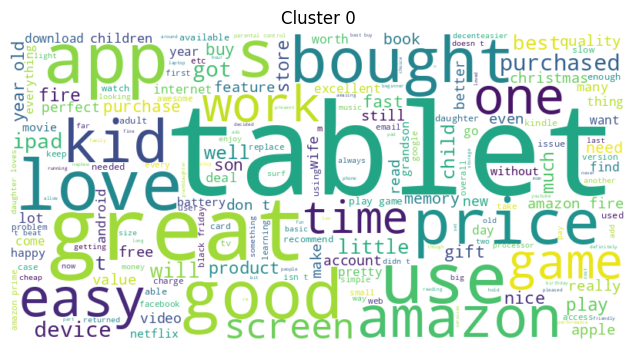

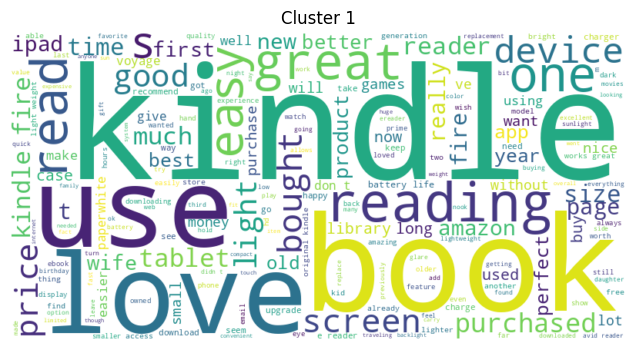

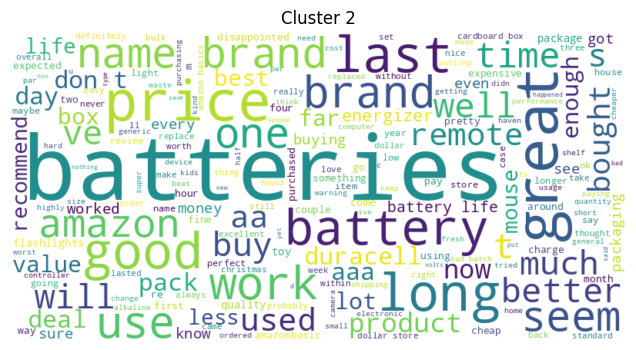

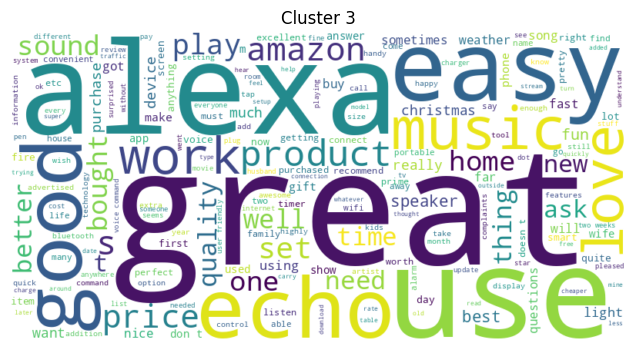

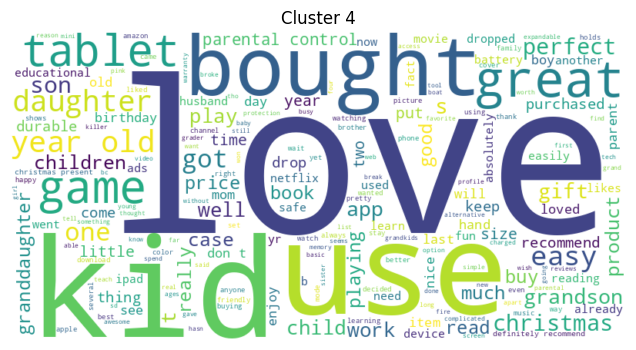

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#generating word cloud per cluster
for cluster_id in sorted(sample_df["cluster"].unique()):
    text = " ".join(sample_df[sample_df["cluster"] == cluster_id]["clean_review"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Cluster {cluster_id}")
    plt.axis("off")
    plt.show()


## Clustering Evaluation
- Evaluating cluster quality using Silhouette Score.

In [21]:
from sklearn.metrics import silhouette_score

# calculating silhouette score
score = silhouette_score(embeddings, sample_df["cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.067854665


## Clustering Insights

- Silhouette score is relatively low (~0.07), indicating weak cluster separation
- This is expected for text data, where reviews often share similar vocabulary
- Despite the low score, clusters show meaningful themes when inspecting top words
- Therefore, qualitative evaluation (top words, examples) is more informative than quantitative metrics alone